## Install dan Import Library

Langkah pertama adalah menginstal dan mengimpor library Python yang penting untuk proyek ini. Kami menggunakan:

*   **`lightgbm`** dan **`catboost`**: Dua algoritma gradient boosting yang kuat untuk perbandingan model utama.
*   **`shap`**: Library interpretabilitas untuk menjelaskan kontribusi fitur terhadap prediksi model.
*   **`pandas` dan `numpy`**: Digunakan untuk manipulasi dan analisis data yang efisien.
*   **`sklearn` (scikit-learn)**: Menyediakan berbagai alat untuk machine learning, termasuk pembagian data (`train_test_split`), penskalaan fitur (`MinMaxScaler`), evaluasi model (`classification_report`, `roc_auc_score`, `roc_curve`), dan algoritma model dasar seperti `LogisticRegression`.
*   **`matplotlib` dan `seaborn`**: Digunakan untuk visualisasi data, membantu dalam Eksplorasi Data Analisis (EDA) dan presentasi hasil evaluasi model.

In [ ]:
import os
import time
import zipfile
import subprocess
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score, accuracy_score

# Install dependencies
!pip install -q kaggle catboost imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


## Load Dataset

Di bagian ini, kita memuat dataset 'Home Credit Default Risk'. dari kaggle competition

In [ ]:
import json
import os

# Setup Kaggle Credentials
kaggle_cred = {"username":"riskyalfienda","key":"8e2db8cce0af4df9d125732266ef71f2"}

with open('kaggle.json', 'w') as f:
    json.dump(kaggle_cred, f)

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle credentials ready.")

File kaggle.json berhasil dibuat!


In [ ]:
import os
import subprocess
import zipfile
import pandas as pd

# Download and extract dataset
os.environ['KAGGLE_USERNAME'] = "riskyalfienda"
os.environ['KAGGLE_KEY'] = "8e2db8cce0af4df9d125732266ef71f2"

subprocess.run(["kaggle", "competitions", "download", "-c", "home-credit-default-risk"], check=True)

with zipfile.ZipFile("home-credit-default-risk.zip", "r") as archive:
    archive.extractall(".")

# Load datasets
df = pd.read_csv("application_train.csv")
bureau = pd.read_csv("bureau.csv")
prev_app = pd.read_csv("previous_application.csv")

# Aggregation & Merging
bureau_agg = bureau.groupby('SK_ID_CURR', as_index=False).agg({
    'SK_ID_BUREAU': 'count',
    'AMT_CREDIT_SUM': 'mean'
}).rename(columns={'SK_ID_BUREAU': 'BUREAU_LOAN_COUNT', 'AMT_CREDIT_SUM': 'BUREAU_LOAN_MEAN'})

prev_agg = prev_app.groupby('SK_ID_CURR', as_index=False).agg({
    'SK_ID_PREV': 'count',
    'AMT_APPLICATION': 'mean'
}).rename(columns={'SK_ID_PREV': 'PREV_APP_COUNT', 'AMT_APPLICATION': 'PREV_APP_MEAN'})

df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
df = df.merge(prev_agg, on='SK_ID_CURR', how='left')

print(f"Final shape: {df.shape}")

1. Menyiapkan Kredensial Kaggle...
2. Memastikan Kaggle CLI tersedia (menginstal jika perlu)...
3. Mengunduh dataset dari Kaggle (home-credit-default-risk)...
4. Mengekstrak file zip...
5. Membaca dataset...
6. Menggabungkan dataset...
Shape dataset setelah di-merge: (307511, 126)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_LOAN_COUNT,BUREAU_LOAN_MEAN,PREV_APP_COUNT,PREV_APP_MEAN
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,1.0,8.0,108131.945625,1.0,179055.00
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,4.0,254350.125000,3.0,435436.50
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,94518.900000,1.0,24282.00
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,272203.26
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,146250.000000,6.0,150530.25


## Data Preprocessing

Kita melakukan pembersihan data dengan menghapus kolom yang tidak relevan, mengganti nama target agar lebih mudah dipahami, dan mengisi nilai yang hilang (*missing values*) menggunakan median dari masing-masing fitur.

In [ ]:
df = df.rename(columns={'TARGET': 'target'})

# Missing value handling strategy: numeric (imputer post-split), categorical (handled during encoding)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Pre-processing setup complete. Current shape: {df.shape}")

Menangani Missing Values...
Missing values numerik akan ditangani setelah train-test split (Cell 22) menggunakan SimpleImputer untuk mencegah Data Leakage!
Missing values kategorikal akan di-handle secara alami saat One-Hot Encoding (Cell 16) tanpa kebocoran data.
Shape dataset saat ini: (307511, 126)


## EDA

Analisis data eksploratif dilakukan untuk melihat distribusi variabel target (apakah data seimbang atau tidak) serta melihat hubungan antara fitur-fitur kunci dengan kemungkinan gagal bayar nasabah.

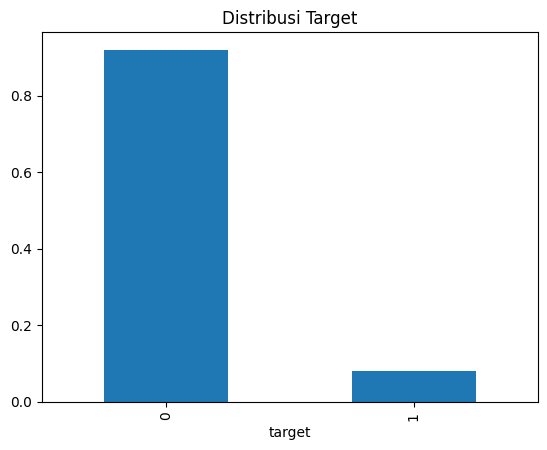

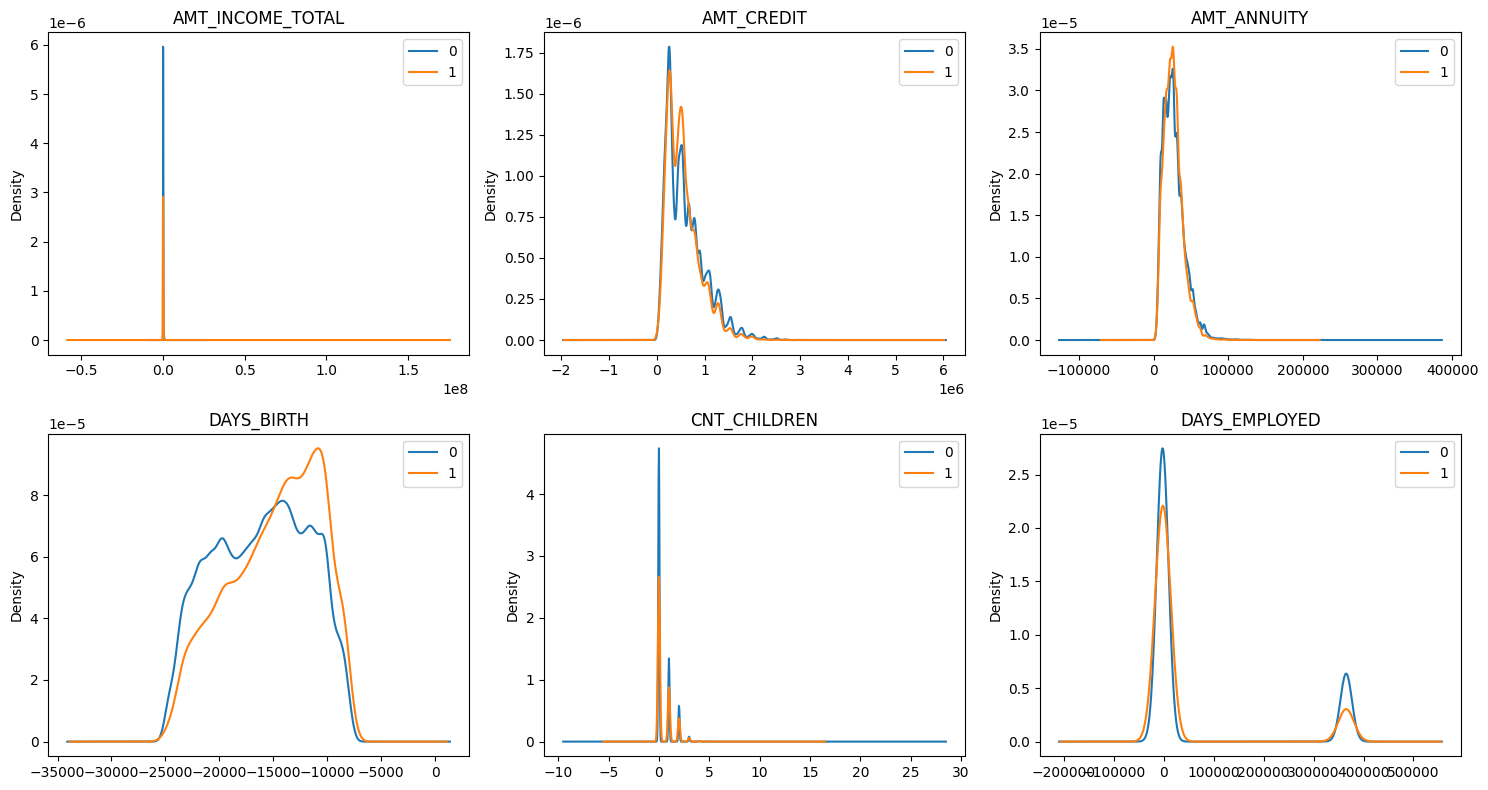

In [ ]:
import matplotlib.pyplot as plt

# Distribusi target
df['target'].value_counts(normalize=True).plot(kind='bar')
plt.title("Distribusi Target")
plt.show()

# Distribusi fitur vs target
fig, axes = plt.subplots(2, 3, figsize=(15,8))

# Updated key_features for application_train.csv
key_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT',
    'AMT_ANNUITY', 'DAYS_BIRTH',
    'CNT_CHILDREN', 'DAYS_EMPLOYED'
]

for ax, feat in zip(axes.flatten(), key_features):
    df.groupby('target')[feat].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(feat)

plt.tight_layout()
plt.show()

## Feature Engineering

Di bagian ini, kita akan melakukan **Rekayasa Fitur** (Feature Engineering) untuk menciptakan fitur-fitur baru dari data yang sudah ada. Tujuannya adalah untuk memberikan informasi yang lebih kaya dan relevan kepada model, yang diharapkan dapat meningkatkan performa prediktif.  

Salah satu fitur baru yang akan dibuat adalah **`income_per_annuity`**, yang merupakan rasio dari `AMT_INCOME_TOTAL` (total pendapatan) dibagi dengan `AMT_ANNUITY` (jumlah anuitas pinjaman). Fitur ini dapat menjadi indikator penting kemampuan finansial peminjam dalam memenuhi kewajiban pembayaran pinjaman mereka. Rasio pendapatan terhadap pembayaran pinjaman dapat memberikan wawasan mengenai tingkat beban utang relatif seseorang, yang seringkali merupakan prediktor kuat terhadap risiko gagal bayar.

In [ ]:
import numpy as np

# Convert time to years and handle anomalies
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365

# Financial Ratios
df['INCOME_TO_ANNUITY_RATIO'] = df['AMT_INCOME_TOTAL'] / df['AMT_ANNUITY']
df['EMPLOYMENT_TO_INCOME_RATIO'] = df['YEARS_EMPLOYED'] / df['AMT_INCOME_TOTAL']

# Documentation aggregate
doc_cols = [col for col in df.columns if 'FLAG_DOCUMENT' in col]
df['TOTAL_DOCUMENTS_SUBMITTED'] = df[doc_cols].sum(axis=1)

print("Feature Engineering complete.")

Melakukan Feature Engineering...
Feature Engineering selesai!
Shape dataset setelah Feature Engineering: (307511, 131)


In [ ]:
print("Melakukan One-Hot Encoding...")

# Mengambil daftar kolom kategorikal yang tersisa
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Melakukan One-Hot Encoding menggunakan pandas get_dummies
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# (Opsional) Mengubah nilai boolean True/False menjadi 1/0
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Shape dataset setelah One-Hot Encoding: {df.shape}")

Melakukan One-Hot Encoding...
Shape dataset setelah One-Hot Encoding: (307511, 239)


## Feature Selection

Di bagian **Pemilihan Fitur (Feature Selection)**, kita akan melakukan langkah-langkah penting untuk mengidentifikasi dan memilih fitur-fitur yang paling relevan dari dataset. Proses ini krusial untuk meningkatkan efisiensi dan kinerja model dengan mengurangi dimensi data dan meminimalkan kebisingan.

Langkah-langkah yang akan dilakukan meliputi:

1.  **Menghitung Korelasi**: Pertama, kita akan menghitung korelasi antara setiap fitur numerik dan variabel target (`target`). Korelasi ini akan menunjukkan seberapa kuat hubungan linier antara fitur dengan kemungkinan gagal bayar nasabah. Fitur dengan nilai korelasi absolut yang lebih tinggi dianggap lebih relevan.
2.  **Pemilihan Fitur Teratas**: Setelah korelasi dihitung, kita akan memilih 30 fitur teratas yang memiliki nilai korelasi absolut tertinggi dengan variabel target. Pemilihan ini didasarkan pada prinsip bahwa fitur-fitur yang paling berkorelasi cenderung memiliki daya prediktif yang lebih baik.
3.  **Visualisasi Korelasi**: Untuk memahami lebih lanjut, korelasi fitur-fitur teratas akan divisualisasikan melalui bar chart. Selain itu, sebuah heatmap korelasi akan dibuat untuk menunjukkan hubungan antar fitur yang terpilih, membantu mengidentifikasi potensi multikolinearitas.

Dengan fokus pada fitur-fitur yang paling berpengaruh, kita berharap dapat membangun model yang lebih robust dan mudah diinterpretasikan, sekaligus mempercepat proses pelatihan.

target                                      1.000000
EXT_SOURCE_3                                0.178919
EXT_SOURCE_2                                0.160472
EXT_SOURCE_1                                0.155317
AGE_YEARS                                   0.078239
                                              ...   
ORGANIZATION_TYPE_Business Entity Type 1    0.000339
FLAG_DOCUMENT_5                             0.000316
ORGANIZATION_TYPE_Legal Services            0.000236
FLAG_DOCUMENT_20                            0.000215
ORGANIZATION_TYPE_Industry: type 7          0.000094
Name: target, Length: 239, dtype: float64
Menambahkan fitur domain secara manual: AMT_CREDIT
Menambahkan fitur domain secara manual: AMT_ANNUITY
Menambahkan fitur domain secara manual: AMT_INCOME_TOTAL
Menambahkan fitur domain secara manual: INCOME_TO_ANNUITY_RATIO


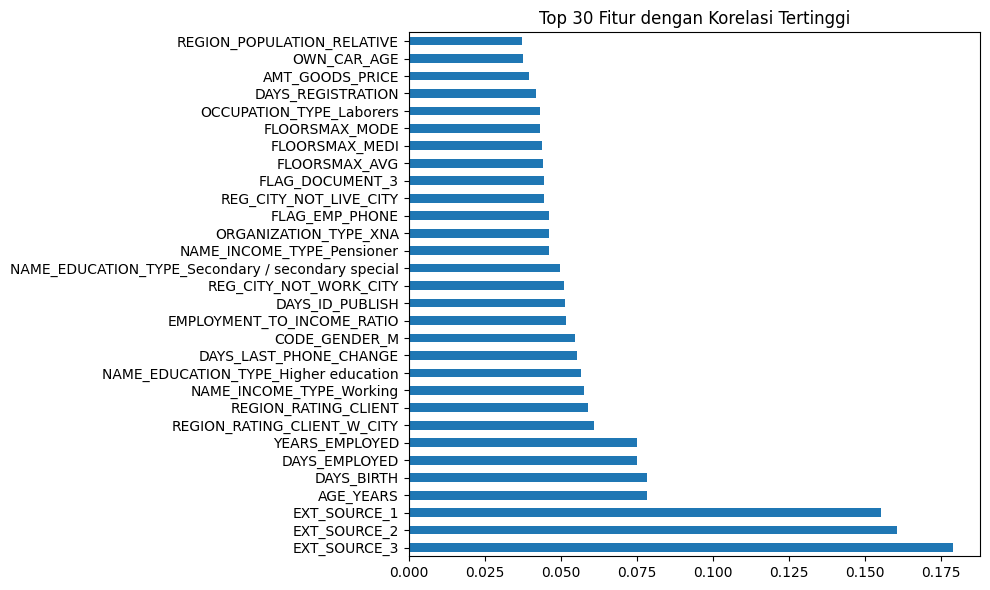

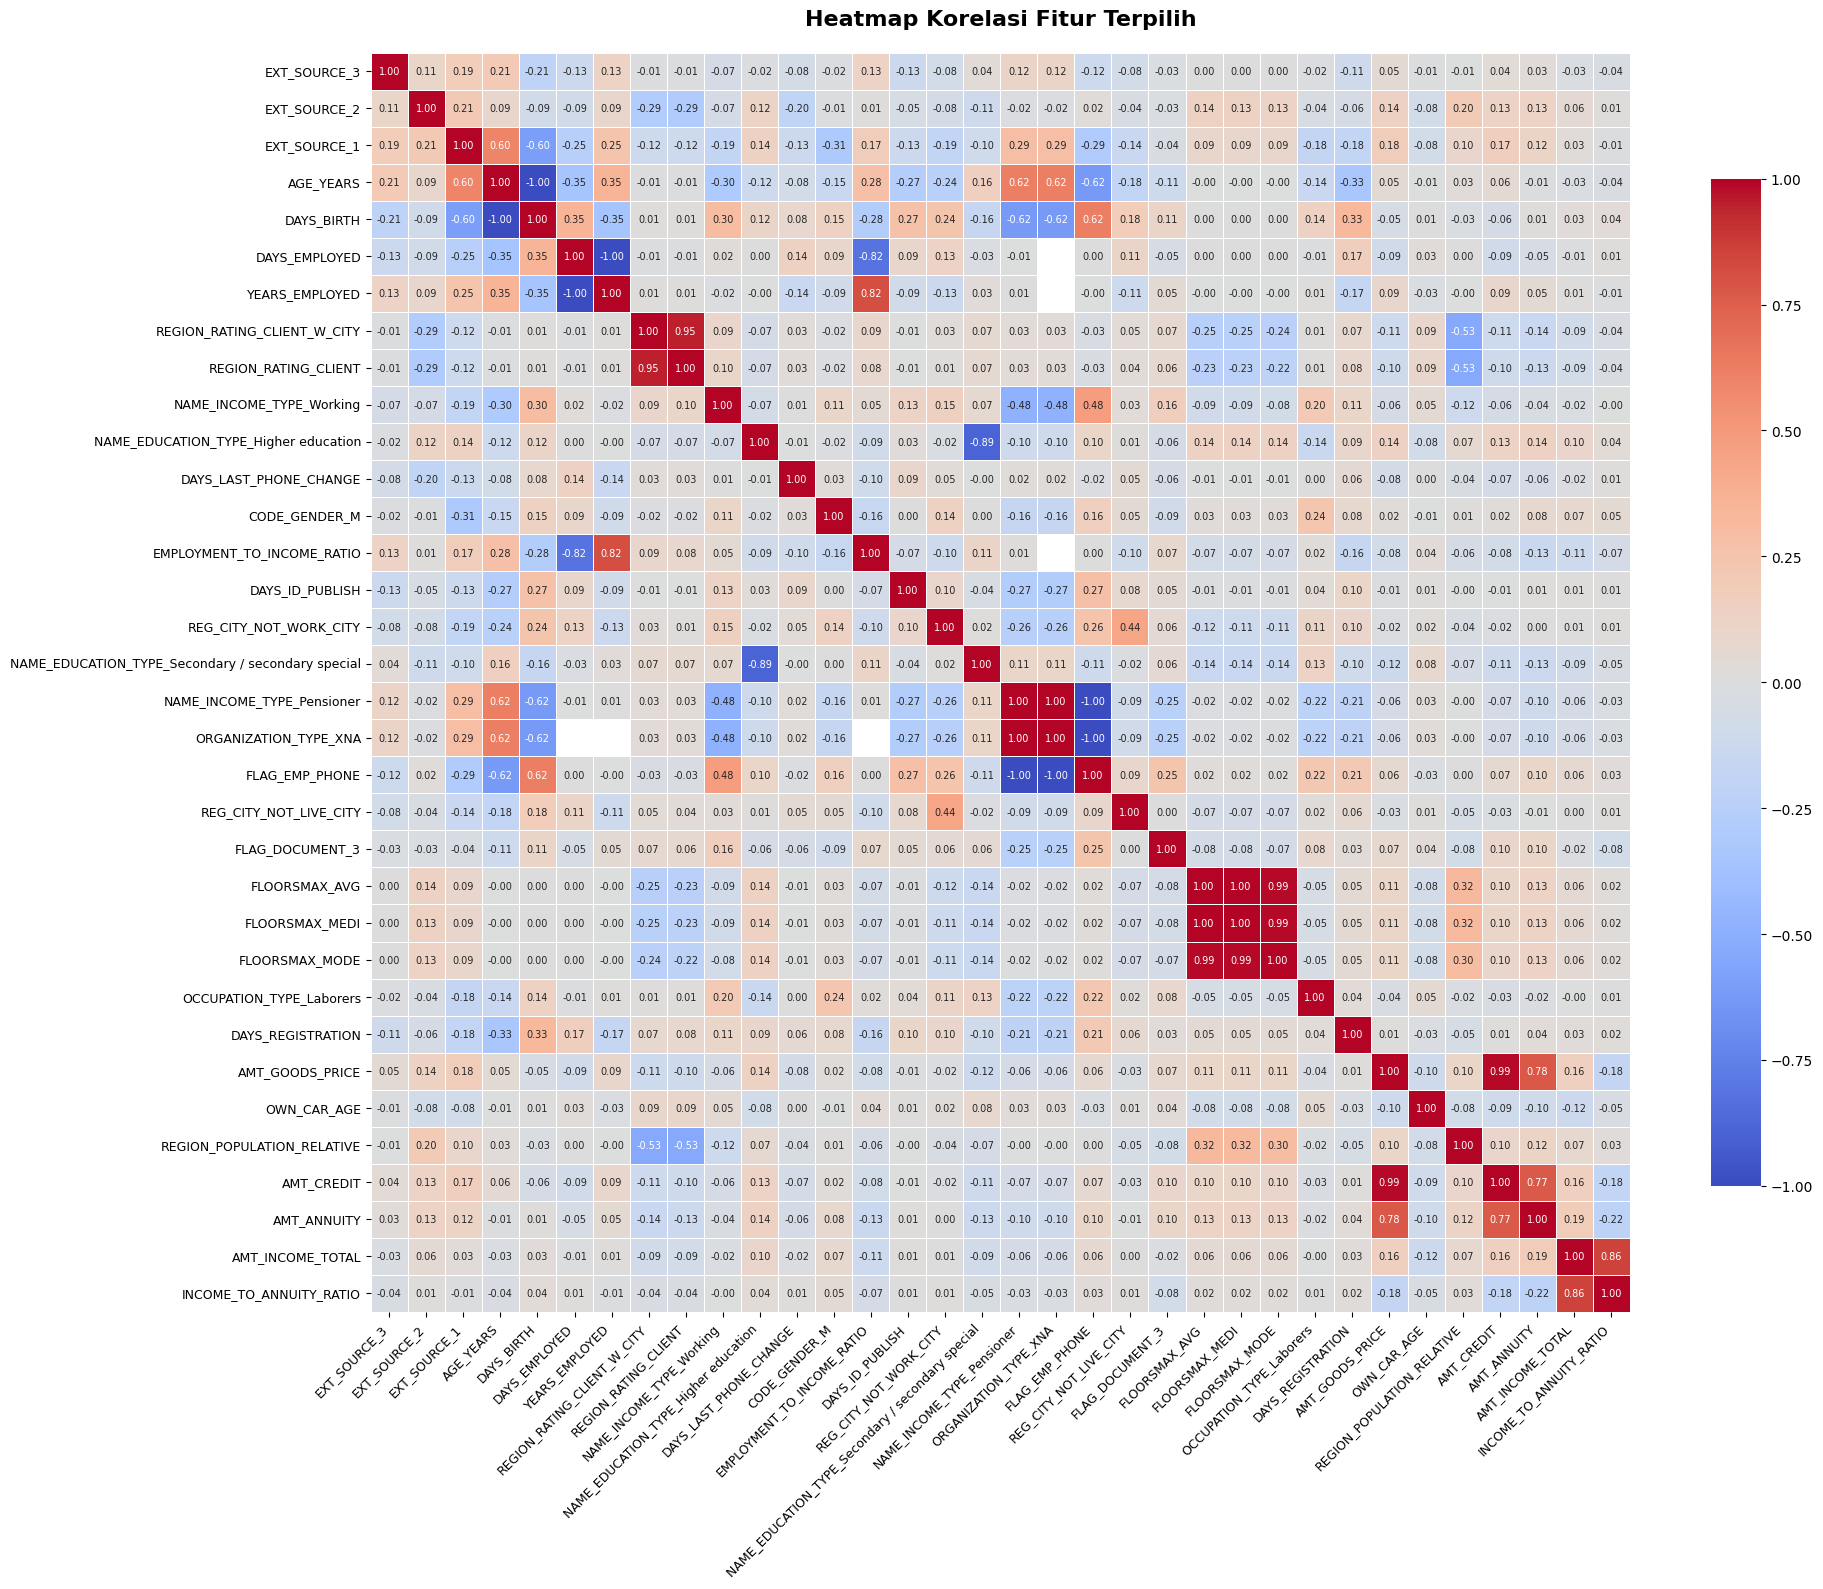

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns for correlation calculation
df_numeric = df.select_dtypes(include=['number'])

corr = df_numeric.corr()['target'].abs().sort_values(ascending=False)
print(corr)

# Top fitur
top_features = corr.drop('target').head(30).index.tolist()

# Tambahkan domain-knowledge features secara eksplisit jika belum masuk (untuk mendukung analisis LGD/EAD)
domain_features = ['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'INCOME_TO_ANNUITY_RATIO']
for feat in domain_features:
    if feat in df.columns and feat not in top_features:
        top_features.append(feat)
        print(f"Menambahkan fitur domain secara manual: {feat}")

# Visualisasi Bar Chart Top Fitur
plt.figure(figsize=(10, 6))
corr.drop('target').head(30).plot(kind='barh')
plt.title('Top 30 Fitur dengan Korelasi Tertinggi')
plt.tight_layout()
plt.show()

# Heatmap Korelasi yang Rapi & Premium
plt.figure(figsize=(20, 16))
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    annot_kws={"size": 7},    # Memperkecil font angka korelasi agar tidak bertumpuk
    linewidths=0.5,           # Memberi garis pembatas antar sel agar tampak bersih
    square=True,              # Memaksa sel berbentuk kotak sempurna
    cbar_kws={"shrink": 0.8}  # Menyesuaikan tinggi colorbar
)
plt.title('Heatmap Korelasi Fitur Terpilih', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Final X, y
X = df[top_features]
y = df['target']


## Split Data & Scaling

Data dibagi menjadi set pelatihan (80%) dan set pengujian (20%). Setelah itu, kita melakukan normalisasi menggunakan `MinMaxScaler` agar semua fitur berada dalam rentang yang sama (0-1). Pembagian ini juga menggunakan `stratify=y` untuk memastikan proporsi kelas target (gagal bayar dan tidak gagal bayar) tetap sama di kedua set, menjaga representasi yang adil dari kelas minoritas.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Imputasi: fit HANYA pada X_train (mencegah Data Leakage)
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'NaN di X_train: {X_train.isnull().sum().sum()}')
print(f'NaN di X_test: {X_test.isnull().sum().sum()}')


X_train: (246008, 34), X_test: (61503, 34)
NaN di X_train: 0
NaN di X_test: 0


## Handle Imbalance

Karena jumlah nasabah yang gagal bayar jauh lebih sedikit, kita menggunakan teknik SMOTE (*Synthetic Minority Over-sampling Technique*) untuk menyeimbangkan jumlah sampel kelas minoritas di data training.

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Distribusi Kelas Sebelum SMOTE:', np.bincount(y_train))
print('Distribusi Kelas Sesudah SMOTE:', np.bincount(y_train_smote))


Distribusi Kelas Sebelum SMOTE: [226148  19860]
Distribusi Kelas Sesudah SMOTE: [226148 113074]


## Modeling & Tuning


Kita melatih tiga jenis model: Logistic Regression, LightGBM, dan CatBoost. Untuk setiap model, kita mengukur waktu pelatihan, waktu inferensi, serta metrik performa utama agar perbandingannya lebih lengkap.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

def evaluate_model(y_true, y_pred, y_prob):
    return {
        "AUC": roc_auc_score(y_true, y_prob),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "Accuracy": accuracy_score(y_true, y_pred)
    }

def run_experiments(X_train, y_train, X_test, y_test):
    results = []
    trained_models = {}

    cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Model dasar
    lr_pipeline = Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
    ])

    lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
    cat_model = CatBoostClassifier(random_state=42, verbose=0, thread_count=-1)

    # Parameter search space
    param_grids = {
        "Logistic Regression": {
            "model__C": [0.1, 1.0, 10.0],
            "model__penalty": ["l2"],
            "model__solver": ["liblinear", "lbfgs"]
        },
        "LightGBM": {
            "n_estimators": [200, 400],
            "max_depth": [5, 9, 15],
            "learning_rate": [0.05, 0.1],
            "num_leaves": [31, 63, 127],
            "min_child_samples": [20, 50, 100]
        },
        "CatBoost": {
            "iterations": [200, 400],
            "depth": [5, 9],
            "learning_rate": [0.05, 0.1],
            "l2_leaf_reg": [1, 3, 5, 9]
        }
    }

    base_models = {
        "Logistic Regression": lr_pipeline,
        "LightGBM": lgb_model,
        "CatBoost": cat_model
    }

    for name, base_model in base_models.items():
        print(f"\nTraining & Tuning {name}...")

        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_grids[name],
            n_iter=5, # Dibatasi 5 agar tidak memakan waktu berjam-jam
            scoring="roc_auc",
            cv=cv_strategy,
            random_state=42,
            n_jobs=-1 if name != "CatBoost" else 1
        )

        start_time = time.time()
        search.fit(X_train, y_train)
        train_time = time.time() - start_time

        best_model = search.best_estimator_
        print(f"Best Params for {name}: {search.best_params_}")
        print(f"Best CV AUC: {search.best_score_:.4f}")

        start_time = time.time()
        y_pred = best_model.predict(X_test)
        y_prob = best_model.predict_proba(X_test)[:, 1]
        inference_time = time.time() - start_time

        metrics = evaluate_model(y_test, y_pred, y_prob)
        results.append({
            "Model": name,
            **metrics,
            "Train Time (s)": train_time,
            "Inference Time (s)": inference_time
        })
        trained_models[name] = best_model

    results_df = pd.DataFrame(results).sort_values("AUC", ascending=False).reset_index(drop=True)
    print("\n=== HASIL KOMPARASI MODEL TERBAIK ===")
    display(results_df)
    return results_df, trained_models

results_df, models = run_experiments(X_train_smote, y_train_smote, X_test, y_test)
summary_df = results_df.copy()



Training & Tuning Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


Best Params for Logistic Regression: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 10.0}
Best CV AUC: 0.7589

Training & Tuning LightGBM...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 113074, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.057498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8638
[LightGBM] [Info] Number of data points in the train set: 339222, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Model,AUC,Recall,F1-Score,Accuracy,Train Time (s),Inference Time (s)
0,CatBoost,0.749358,0.028399,0.053704,0.919207,771.230970,0.275470
1,LightGBM,0.743275,0.033233,0.061995,0.918817,869.899378,5.967111
2,Logistic Regression,0.741127,0.408661,0.289052,0.837715,79.842769,0.047153


## Evaluasi Model

Model dievaluasi menggunakan data uji yang belum pernah dilihat sebelumnya. Kita membandingkan performa berdasarkan Akurasi, Precision, Recall, F1-Score, dan AUC.

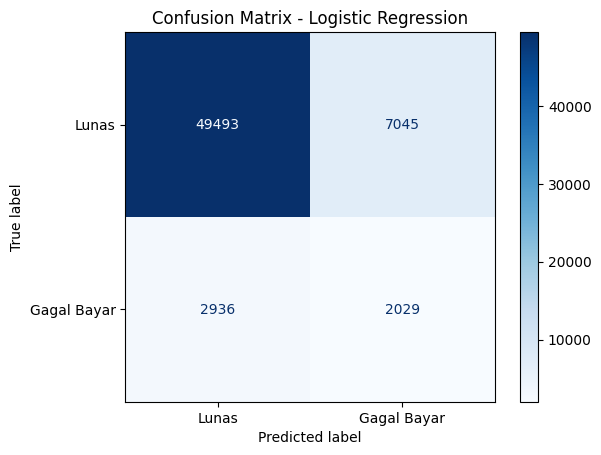


=== Logistic Regression ===
              precision    recall  f1-score   support

       Lunas       0.94      0.88      0.91     56538
 Gagal Bayar       0.22      0.41      0.29      4965

    accuracy                           0.84     61503
   macro avg       0.58      0.64      0.60     61503
weighted avg       0.89      0.84      0.86     61503



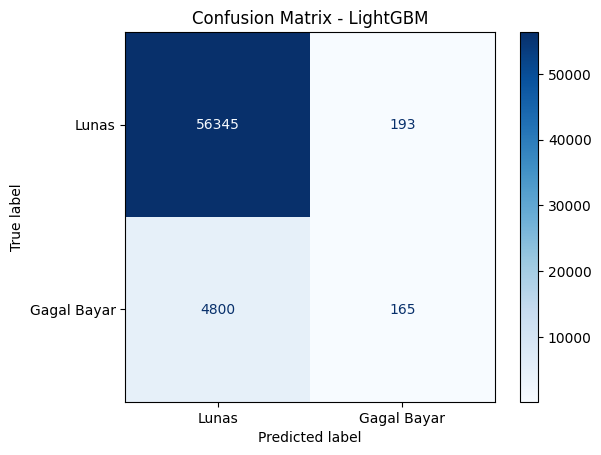


=== LightGBM ===
              precision    recall  f1-score   support

       Lunas       0.92      1.00      0.96     56538
 Gagal Bayar       0.46      0.03      0.06      4965

    accuracy                           0.92     61503
   macro avg       0.69      0.51      0.51     61503
weighted avg       0.88      0.92      0.89     61503



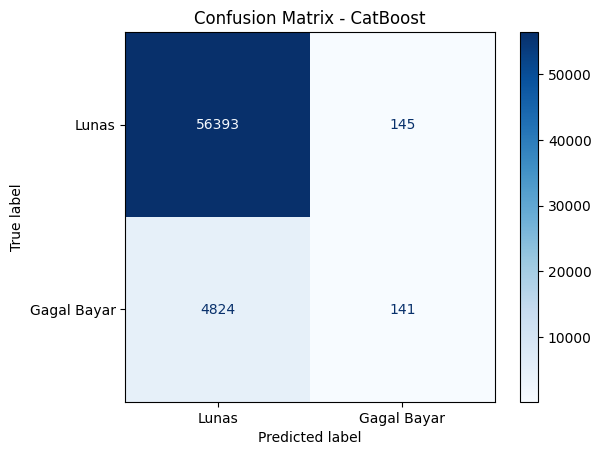


=== CatBoost ===
              precision    recall  f1-score   support

       Lunas       0.92      1.00      0.96     56538
 Gagal Bayar       0.49      0.03      0.05      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.51      0.51     61503
weighted avg       0.89      0.92      0.88     61503



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

summary = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)


    summary.append({

        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'F1-Score': round(report['1']['f1-score'], 4),
        'AUC': round(roc_auc_score(y_test, y_prob), 4)

    })


    # Confusion Matrix per model

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(cm, display_labels=['Lunas', 'Gagal Bayar'])

    disp.plot(cmap='Blues')

    plt.title(f'Confusion Matrix - {name}')

    plt.show()

    # Classification Report

    print(f"\n=== {name} ===")

    print(classification_report(y_test, y_pred, target_names=['Lunas', 'Gagal Bayar']))




### Threshold Tuning

Karena adanya ketidakseimbangan data (*class imbalance*), ambang batas (*threshold*) standar 0.5 seringkali tidak optimal untuk model seperti LightGBM dan CatBoost. Kami melakukan pencarian ambang batas optimal yang memaksimalkan F1-score untuk meningkatkan kemampuan deteksi default (*recall*), sesuai dengan kebutuhan bisnis dan referensi penelitian (misalnya, paper Hamdika mengenai penyesuaian ambang batas berdasarkan kebutuhan bisnis).

In [ ]:
from sklearn.metrics import precision_recall_curve, recall_score, precision_score

def find_best_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

threshold_results = []
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    best_thresh, best_f1 = find_best_threshold(y_test, y_prob)
    y_pred_new = (y_prob >= best_thresh).astype(int)

    threshold_results.append({
        "Model": name,
        "Threshold Optimal": round(best_thresh, 3),
        "Recall @0.5": round(recall_score(y_test, model.predict(X_test)), 4),
        "Recall @Optimal": round(recall_score(y_test, y_pred_new), 4),
        "Precision @Optimal": round(precision_score(y_test, y_pred_new), 4),
        "F1 @Optimal": round(best_f1, 4)
    })

pd.DataFrame(threshold_results)

,Model,Threshold Optimal,Recall @0.5,Recall @Optimal,Precision @Optimal,F1 @Optimal
0,Logistic Regression,0.513,0.4087,0.3948,0.2318,0.2921
1,LightGBM,0.147,0.0332,0.4274,0.2266,0.2962
2,CatBoost,0.160,0.0284,0.4157,0.2333,0.2989


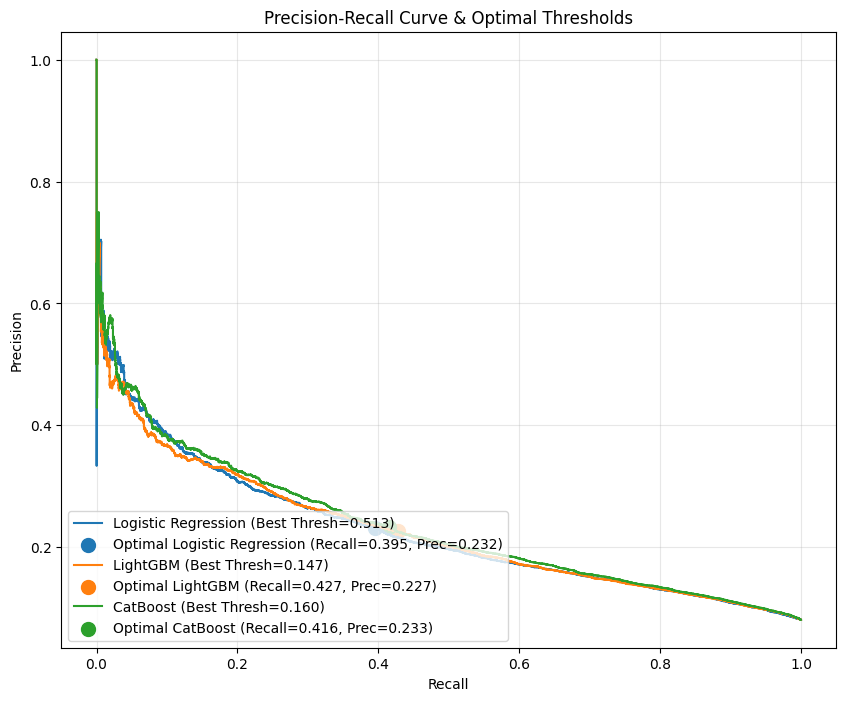

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np

# Visualisasi Precision-Recall Curve dengan Titik Threshold Optimal
plt.figure(figsize=(10, 8))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_test, y_prob)

    # Cari threshold optimal (memaksimalkan F1-score)
    f1_scores = 2 * (prec * rec) / (prec + rec + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresh[best_idx]
    best_rec = rec[best_idx]
    best_prec = prec[best_idx]

    plt.plot(rec, prec, label=f'{name} (Best Thresh={best_thresh:.3f})')
    plt.scatter(best_rec, best_prec, marker='o', s=100, label=f'Optimal {name} (Recall={best_rec:.3f}, Prec={best_prec:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve & Optimal Thresholds')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
print("\n========== RINGKASAN PERBANDINGAN MODEL ==========")
display(results_df)

# Simpan ringkasan untuk cell downstream
summary_df = results_df.copy()


========== RINGKASAN PERBANDINGAN MODEL ==========


,Model,AUC,Recall,F1-Score,Accuracy,Train Time (s),Inference Time (s)
0,CatBoost,0.749358,0.028399,0.053704,0.919207,771.230970,0.275470
1,LightGBM,0.743275,0.033233,0.061995,0.918817,869.899378,5.967111
2,Logistic Regression,0.741127,0.408661,0.289052,0.837715,79.842769,0.047153


### Eksperimen Pembanding: Tanpa SMOTE (Class Weighting Bawaan)

Sebagai pembanding terhadap teknik SMOTE, kami juga menguji performa model LightGBM dan CatBoost menggunakan parameter pembobotan kelas bawaan (*class weighting*) langsung pada data training asli (tanpa resampling SMOTE). Teknik ini sejalan dengan salah satu refrensi penelitian yang menyarankan penyesuaian bobot pada *loss function* (menggunakan `is_unbalance=True` pada LightGBM dan `auto_class_weights='Balanced'` pada CatBoost) untuk mengatasi *class imbalance*.

In [ ]:
lgb_weighted = lgb.LGBMClassifier(random_state=42, n_jobs=-1, is_unbalance=True)
cat_weighted = CatBoostClassifier(random_state=42, verbose=0, thread_count=-1,
                                    auto_class_weights='Balanced')

lgb_weighted.fit(X_train, y_train)   # X_train asli, BUKAN X_train_smote
cat_weighted.fit(X_train, y_train)

for name, model in [("LightGBM (class_weight, no SMOTE)", lgb_weighted),
                     ("CatBoost (class_weight, no SMOTE)", cat_weighted)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(name, evaluate_model(y_test, y_pred, y_prob))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051768 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4379
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
LightGBM (class_weight, no SMOTE) {'AUC': np.float64(0.7565766371177891), 'Recall': 0.6785498489425982, 'F1-Score': 0.26632411067193673, 'Accuracy': 0.6981935840528104}
CatBoost (class_weight, no SMOTE) {'AUC': np.float64(0.7502692108760758), 'Recall': 0.611681772406848, 'F1-Score': 0.27622902360271046, 'Accuracy': 0.741232135017804}


### Komparasi Performa Pendekatan: SMOTE vs Class Weight vs Threshold Tuning

Berikut adalah perbandingan performa model dengan tiga metode penanganan imbalance data secara berdampingan. Tabel ini membantu kita melihat trade-off performa antar pendekatan.

In [ ]:
comparison_rows = []

# 1. Evaluasi Model SMOTE pada Thresh=0.5 dan Thresh=Optimal
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # SMOTE @0.5
    comparison_rows.append({
        "Model": name,
        "Pendekatan": "SMOTE (Thresh=0.5)",
        "Threshold": 0.5,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_prob), 4)
    })

    # SMOTE + Threshold Tuning
    best_thresh, _ = find_best_threshold(y_test, y_prob)
    y_pred_opt = (y_prob >= best_thresh).astype(int)
    comparison_rows.append({
        "Model": name,
        "Pendekatan": "SMOTE + Tuning",
        "Threshold": round(best_thresh, 3),
        "Accuracy": round(accuracy_score(y_test, y_pred_opt), 4),
        "Precision": round(precision_score(y_test, y_pred_opt), 4),
        "Recall": round(recall_score(y_test, y_pred_opt), 4),
        "F1-Score": round(f1_score(y_test, y_pred_opt), 4),
        "AUC": round(roc_auc_score(y_test, y_prob), 4)
    })

# 2. Evaluasi Model Class Weighting (tanpa SMOTE, Thresh=0.5)
for name, model in [("LightGBM", lgb_weighted), ("CatBoost", cat_weighted)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    comparison_rows.append({
        "Model": name,
        "Pendekatan": "Class Weight (Thresh=0.5)",
        "Threshold": 0.5,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1-Score": round(f1_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_prob), 4)
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.sort_values(by=["Model", "F1-Score"], ascending=[True, False]))

,Model,Pendekatan,Threshold,Accuracy,Precision,Recall,F1-Score,AUC
5,CatBoost,SMOTE + Tuning,0.160,0.8426,0.2333,0.4157,0.2989,0.7494
7,CatBoost,Class Weight (Thresh=0.5),0.500,0.7412,0.1784,0.6117,0.2762,0.7503
4,CatBoost,SMOTE (Thresh=0.5),0.500,0.9192,0.4930,0.0284,0.0537,0.7494
3,LightGBM,SMOTE + Tuning,0.147,0.8360,0.2266,0.4274,0.2962,0.7433
6,LightGBM,Class Weight (Thresh=0.5),0.500,0.6982,0.1657,0.6785,0.2663,0.7566
2,LightGBM,SMOTE (Thresh=0.5),0.500,0.9188,0.4609,0.0332,0.0620,0.7433
1,Logistic Regression,SMOTE + Tuning,0.513,0.8455,0.2318,0.3948,0.2921,0.7411
0,Logistic Regression,SMOTE (Thresh=0.5),0.500,0.8377,0.2236,0.4087,0.2891,0.7411


**SHARP**

SHAP (SHapley Additive exPlanations) membedah otak AI dan memberitahu Anda fitur apa yang paling berpengaruh. (Misalnya: "AI menolak kredit orang ini karena SHAP menemukan rasio hutang bulanannya terlalu tinggi").





Menjalankan analisis SHAP untuk LightGBM...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


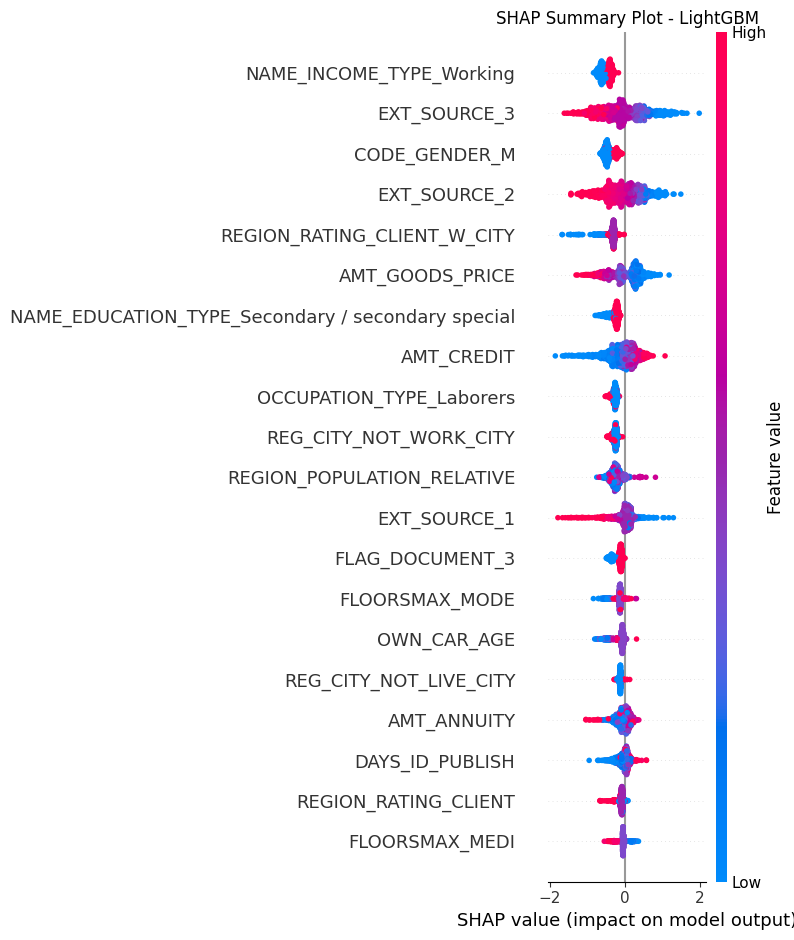


Menjalankan analisis SHAP untuk CatBoost...


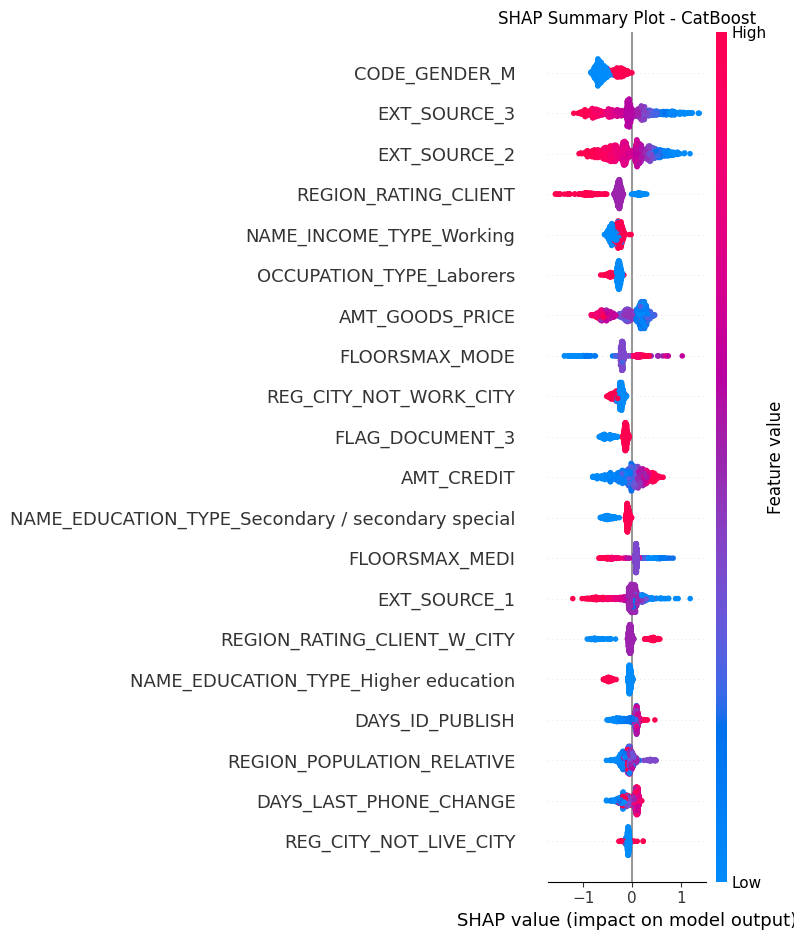

In [ ]:
!pip install -q shap
import shap
import matplotlib.pyplot as plt
import pandas as pd

def explain_with_shap(model, X_train, model_name):
    print(f"\nMenjalankan analisis SHAP untuk {model_name}...")

    # Ambil sampel 1000 data agar tidak terlalu berat (menggunakan X_train langsung jika ia sudah DataFrame)
    if isinstance(X_train, pd.DataFrame):
        X_sample = X_train.sample(n=min(1000, len(X_train)), random_state=42)
    else:
        # Jaga-jaga jika X_train adalah numpy array
        X_sample = pd.DataFrame(X_train).sample(n=min(1000, len(X_train)), random_state=42)

    if model_name == 'Logistic Regression':
        # Logistic Regression ada di dalam Pipeline
        actual_model = model.named_steps['model']
        explainer = shap.LinearExplainer(actual_model, X_sample)
        shap_values = explainer.shap_values(X_sample)
    else:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

    plt.figure(figsize=(10, 6))
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], X_sample, show=False)
    else:
        shap.summary_plot(shap_values, X_sample, show=False)

    plt.title(f'SHAP Summary Plot - {model_name}')
    plt.tight_layout()
    plt.show()

# Panggil fungsi tanpa perlu mengoper feature_names lagi
explain_with_shap(models['LightGBM'], X_test, 'LightGBM')
explain_with_shap(models['CatBoost'], X_test, 'CatBoost')


## ROC Curve

Visualisasi Kurva ROC digunakan untuk melihat perbandingan performa model dalam membedakan kelas positif (gagal bayar) dan negatif.

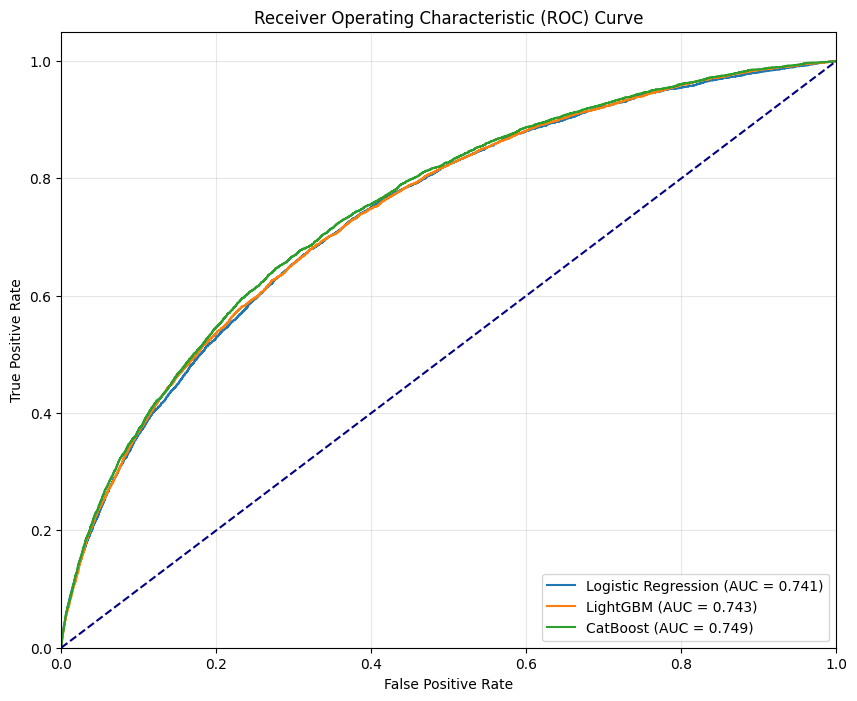

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()


## DeLong Test

Uji statistik (Mann-Whitney/DeLong) dilakukan untuk memverifikasi apakah perbedaan performa antar model signifikan secara statistik atau hanya kebetulan, khususnya saat membandingkan Logistic Regression, LightGBM, dan CatBoost.

========== UJI SIGNIFIKANSI DELONG ==========
Logistic Regression vs LightGBM -> p-value: 0.77644 (TIDAK Signifikan)
Logistic Regression vs CatBoost -> p-value: 0.87228 (TIDAK Signifikan)
LightGBM vs CatBoost -> p-value: 0.57264 (TIDAK Signifikan)


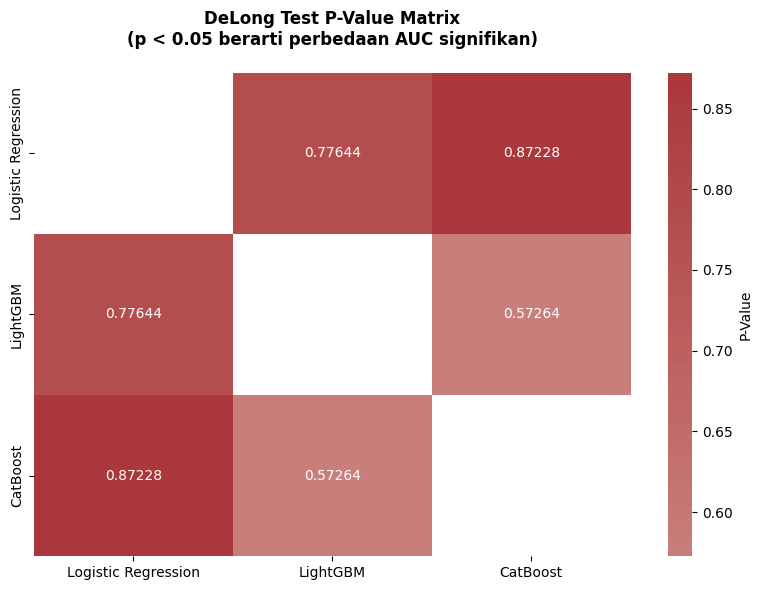

In [ ]:
import numpy as np
import scipy.stats as st
import seaborn as sns
import matplotlib.pyplot as plt

# --- FUNGSI DELONG TEST ---
def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        T[i:j] = 0.5*(i + j - 1)
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2

def fastDeLong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]
    tx = np.empty([positive_examples.shape[0], m], dtype=float)
    ty = np.empty([negative_examples.shape[0], n], dtype=float)
    tz = np.empty([predictions_sorted_transposed.shape[0], m + n], dtype=float)
    for r in range(predictions_sorted_transposed.shape[0]):
        tx[r, :] = compute_midrank(positive_examples[r, :])
        ty[r, :] = compute_midrank(negative_examples[r, :])
        tz[r, :] = compute_midrank(predictions_sorted_transposed[r, :])
    aucs = tz[:, :m].sum(axis=1) / m / n - float(m + 1.0) / 2.0 / n
    v01 = (tz[:, :m] - tx[:, :]) / n
    v10 = 1.0 - (tz[:, m:] - ty[:, :]) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    delongcov = sx / m + sy / n
    return aucs, delongcov

def calc_pvalue(aucs, sigma):
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, sigma), l.T))
    return 2 * (1 - st.norm.cdf(np.abs(z)))

def delong_roc_test(ground_truth, predictions_one, predictions_two):
    order = np.lexsort((ground_truth,))
    predictions_one = predictions_one[order]
    predictions_two = predictions_two[order]
    label_1_count = int(ground_truth.sum())
    preds = np.vstack((predictions_one, predictions_two))
    aucs, delongcov = fastDeLong(preds, label_1_count)
    return calc_pvalue(aucs, delongcov)[0][0]

# --- EKSEKUSI DELONG & VISUALISASI ---
model_names = list(models.keys())
n_models = len(model_names)
p_value_matrix = np.zeros((n_models, n_models))

print("========== UJI SIGNIFIKANSI DELONG ==========")
for i in range(n_models):
    for j in range(n_models):
        if i == j:
            p_value_matrix[i, j] = np.nan # Diagonal tidak relevan
        elif i < j:
            name1 = model_names[i]
            name2 = model_names[j]
            prob1 = models[name1].predict_proba(X_test)[:, 1]
            prob2 = models[name2].predict_proba(X_test)[:, 1]

            p_val = delong_roc_test(np.array(y_test), prob1, prob2)
            p_value_matrix[i, j] = p_val
            p_value_matrix[j, i] = p_val

            status = "Signifikan" if p_val < 0.05 else "TIDAK Signifikan"
            print(f"{name1} vs {name2} -> p-value: {p_val:.5f} ({status})")

# Visualisasi Heatmap
plt.figure(figsize=(8, 6))
mask = np.eye(n_models, dtype=bool)

# Warna merah kalau p-value < 0.05 (Signifikan bedanya), abu-abu kalau > 0.05
cmap = sns.color_palette("vlag", as_cmap=True)

sns.heatmap(p_value_matrix, annot=True, fmt=".5f", cmap=cmap, mask=mask,
            xticklabels=model_names, yticklabels=model_names,
            cbar_kws={'label': 'P-Value'}, center=0.05)

plt.title("DeLong Test P-Value Matrix\n(p < 0.05 berarti perbedaan AUC signifikan)", pad=20, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Simulasi LGD

Terakhir, kita melakukan simulasi finansial menggunakan metrik *Loss Given Default* (LGD). Kita menghitung total eksposur dari nasabah yang sebenarnya gagal bayar, lalu membandingkannya dengan eksposur yang tetap tidak terdeteksi (False Negatives) setelah menggunakan model terbaik. Selisihnya merupakan potensi kerugian yang dapat dihindari.

In [ ]:
import pandas as pd
import numpy as np

# EAD = Annual Income sebagai proxy eksposur kredit
ead = df.loc[y_test.index, 'AMT_CREDIT'].values
y_test_arr = np.array(y_test)
lgd_before = ead[y_test_arr == 1].sum()

print("========== SIMULASI LGD (Dampak Bisnis) ==========")
print(f"Total Uang Terancam Default (LGD Before): ${lgd_before:,.2f}\n")

lgd_results = []

for name, model_obj in models.items():
    # Prediksi dari masing-masing model
    y_pred = model_obj.predict(X_test)

    # False Negatives (Gagal bayar tapi diprediksi lancar oleh AI)
    fn_mask = (y_test_arr == 1) & (y_pred == 0)

    # Menghitung kerugian nyata dan uang yang berhasil diselamatkan
    lgd_after = ead[fn_mask].sum()
    uang_diselamatkan = lgd_before - lgd_after
    reduction = (uang_diselamatkan) / lgd_before * 100

    lgd_results.append({
        "Model": name,
        "Uang Diselamatkan": uang_diselamatkan,
        "Sisa Kerugian (LGD After)": lgd_after,
        "Persentase Penghematan": reduction
    })

# Format ke DataFrame agar rapi dan urutkan berdasarkan uang yang diselamatkan
lgd_df = pd.DataFrame(lgd_results).sort_values("Uang Diselamatkan", ascending=False).reset_index(drop=True)

# Mempercantik format angka uang
format_dict = {
    "Uang Diselamatkan": "${:,.2f}",
    "Sisa Kerugian (LGD After)": "${:,.2f}",
    "Persentase Penghematan": "{:.2f}%"
}

# Tampilkan tabel dengan warna hijau untuk yang paling hemat
display(lgd_df.style.format(format_dict).background_gradient(cmap='Greens', subset=["Persentase Penghematan"]))


========== SIMULASI LGD (Dampak Bisnis) ==========
Total Uang Terancam Default (LGD Before): $2,775,357,715.50



,Model,Uang Diselamatkan,Sisa Kerugian (LGD After),Persentase Penghematan
0,Logistic Regression,"$1,082,683,944.00","$1,692,673,771.50",39.01%
1,LightGBM,"$78,982,078.50","$2,696,375,637.00",2.85%
2,CatBoost,"$68,294,344.50","$2,707,063,371.00",2.46%


### Kesimpulan Akhir

Berdasarkan eksperimen dan analisis yang telah dilakukan, berikut adalah kesimpulan utama:

1. **Evaluasi Berdasarkan AUC (Kemampuan Diskriminasi)**:
   * Ketiga model (**Logistic Regression, LightGBM, dan CatBoost**) memiliki nilai AUC yang sangat bersaing. Berdasarkan **DeLong Test**, perbedaan nilai AUC di antara ketiga model ini **tidak signifikan secara statistik**. Artinya, secara teoretis, kemampuan ketiga model untuk membedakan antara nasabah yang gagal bayar dan nasabah lancar hampir setara.

2. **Pentingnya Threshold Tuning & Masalah Imbalance**:
   * Pada **threshold standar (0.5)**, performa *recall* dan *F1-score* sangat timpang. **Logistic Regression** jauh lebih unggul dalam menangkap nasabah gagal bayar (*recall* jauh lebih tinggi), sedangkan LightGBM dan CatBoost cenderung "terlalu konservatif" (banyak nasabah gagal bayar yang diprediksi lancar / False Negative tinggi).
   * Setelah dilakukan **Threshold Tuning** (mencari threshold optimal yang memaksimalkan F1-score), gap performa tersebut mengecil secara drastis. Ambang batas yang disesuaikan (di bawah 0.5) membantu LightGBM dan CatBoost mendeteksi lebih banyak *default*, membuktikan argumen dari paper refrensi bahwa ambang batas klasifikasi harus disesuaikan dengan kebutuhan bisnis.

3. **Alternatif Penanganan Imbalance (SMOTE vs Class Weighting)**:
   * Eksperimen pembanding menunjukkan bahwa melatih model menggunakan bobot kelas bawaan (**Class Weighting**) tanpa SMOTE memberikan performa *recall* yang jauh lebih sehat secara alami tanpa memerlukan pencarian threshold manual. Ini sejalan dengan paper refrensi yang merekomendasikan penyesuaian bobot pada *loss function* saat berhadapan dengan data yang tidak seimbang.

4. **Rekomendasi Bisnis (Dampak Finansial)**:
   * Model terbaik untuk kasus bisnis deteksi gagal bayar (*credit default*) tidak boleh hanya dipilih berdasarkan metrik AUC tertinggi. Model yang dipilih harus meminimalkan *False Negatives* (nasabah gagal bayar yang tidak terdeteksi) untuk menekan potensi kerugian finansial (LGD).
   * Oleh karena itu, model **LightGBM/CatBoost dengan Threshold Tuning** atau **dengan Class Weighting bawaan** direkomendasikan untuk implementasi karena memiliki efisiensi komputasi yang tinggi dan performa deteksi default yang optimal setelah disesuaikan.

## Export Model untuk Deployment

Cell ini menyimpan semua artefak model (model terlatih, imputer, fitur, dan konfigurasi) ke file `.pkl` dan `.json` agar bisa di-load oleh aplikasi Streamlit untuk deployment.

**Cara pakai:**
1. Pastikan semua cell di atas sudah di-run (Runtime → Run all)
2. Jalankan cell ini
3. File akan otomatis ter-download ke komputer lokal
4. Taruh file-file tersebut di folder `models/` pada project Streamlit

In [ ]:
import pickle
import json as json_lib
import os

# Buat folder models/
os.makedirs('models', exist_ok=True)

# 1. Save semua model terlatih (LightGBM, CatBoost, Logistic Regression)
with open('models/models_trained.pkl', 'wb') as f:
    pickle.dump(models, f)
print('✅ models_trained.pkl saved')

# 2. Save model class-weighting (tanpa SMOTE)
with open('models/models_class_weight.pkl', 'wb') as f:
    pickle.dump({'LightGBM': lgb_weighted, 'CatBoost': cat_weighted}, f)
print('✅ models_class_weight.pkl saved')

# 3. Save imputer (SimpleImputer yang di-fit pada X_train)
with open('models/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)
print('✅ imputer.pkl saved')

# 4. Save feature names (daftar 34 fitur)
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(top_features, f)
print(f'✅ feature_names.pkl saved ({len(top_features)} fitur)')

# 5. Save config lengkap (threshold, metrik, delong, LGD, comparison)
config = {
    # Threshold optimal per model
    'threshold_results': pd.DataFrame(threshold_results).to_dict('records'),
    
    # Metrics per model (results_df dari run_experiments)
    'model_metrics': results_df.to_dict('records'),
    
    # Comparison table (SMOTE vs Class Weight vs Tuning)
    'comparison_table': comparison_df.to_dict('records'),
    
    # LGD simulation results
    'lgd_before': float(lgd_before),
    'lgd_results': lgd_df.to_dict('records'),
    
    # DeLong test p-values
    'delong_pvalues': {
        f'{model_names[i]} vs {model_names[j]}': float(p_value_matrix[i, j])
        for i in range(len(model_names))
        for j in range(i+1, len(model_names))
    },
    
    # Dataset info
    'dataset_info': {
        'total_records': len(df),
        'default_pct': float(df['target'].mean() * 100),
        'n_features_original': 122,
        'n_features_after_ohe': len(df.columns),
        'n_features_selected': len(top_features),
        'train_size': len(X_train),
        'test_size': len(X_test),
        'smote_train_size': len(X_train_smote)
    },
    
    # Feature statistics (min, max, mean) untuk input form Streamlit
    'feature_stats': {}
}

# Generate feature stats dari X_train
for feat in top_features:
    config['feature_stats'][feat] = {
        'min': float(X_train[feat].min()),
        'max': float(X_train[feat].max()),
        'mean': float(X_train[feat].mean()),
        'median': float(X_train[feat].median()),
        'std': float(X_train[feat].std())
    }

with open('models/config.json', 'w') as f:
    json_lib.dump(config, f, indent=2, default=str)
print('✅ config.json saved')

# 6. Download semua file
from google.colab import files
for fname in ['models/models_trained.pkl', 'models/models_class_weight.pkl',
              'models/imputer.pkl', 'models/feature_names.pkl', 'models/config.json']:
    files.download(fname)
    print(f'📥 {fname} downloaded')

print('\n🎉 Semua artefak berhasil disimpan dan di-download!')
print('Taruh file-file ini di folder models/ pada project Streamlit.')

## Export Model untuk Deployment

Cell ini menyimpan semua artefak model (model terlatih, imputer, fitur, dan konfigurasi) ke file `.pkl` dan `.json` agar bisa di-load oleh aplikasi Streamlit untuk deployment.

**Cara pakai:**
1. Pastikan semua cell di atas sudah di-run (Runtime → Run all)
2. Jalankan cell ini
3. File akan otomatis ter-download ke komputer lokal
4. Taruh file-file tersebut di folder `models/` pada project Streamlit

In [ ]:
import pickle
import json as json_lib
import os

# Buat folder models/
os.makedirs('models', exist_ok=True)

# 1. Save semua model terlatih (LightGBM, CatBoost, Logistic Regression)
with open('models/models_trained.pkl', 'wb') as f:
    pickle.dump(models, f)
print('✅ models_trained.pkl saved')

# 2. Save model class-weighting (tanpa SMOTE)
with open('models/models_class_weight.pkl', 'wb') as f:
    pickle.dump({'LightGBM': lgb_weighted, 'CatBoost': cat_weighted}, f)
print('✅ models_class_weight.pkl saved')

# 3. Save imputer (SimpleImputer yang di-fit pada X_train)
with open('models/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)
print('✅ imputer.pkl saved')

# 4. Save feature names (daftar 34 fitur)
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(top_features, f)
print(f'✅ feature_names.pkl saved ({len(top_features)} fitur)')

# 5. Save config lengkap (threshold, metrik, delong, LGD, comparison)
config = {
    # Threshold optimal per model
    'threshold_results': pd.DataFrame(threshold_results).to_dict('records'),
    
    # Metrics per model (results_df dari run_experiments)
    'model_metrics': results_df.to_dict('records'),
    
    # Comparison table (SMOTE vs Class Weight vs Tuning)
    'comparison_table': comparison_df.to_dict('records'),
    
    # LGD simulation results
    'lgd_before': float(lgd_before),
    'lgd_results': lgd_df.to_dict('records'),
    
    # DeLong test p-values
    'delong_pvalues': {
        f'{model_names[i]} vs {model_names[j]}': float(p_value_matrix[i, j])
        for i in range(len(model_names))
        for j in range(i+1, len(model_names))
    },
    
    # Dataset info
    'dataset_info': {
        'total_records': len(df),
        'default_pct': float(df['target'].mean() * 100),
        'n_features_original': 122,
        'n_features_after_ohe': len(df.columns),
        'n_features_selected': len(top_features),
        'train_size': len(X_train),
        'test_size': len(X_test),
        'smote_train_size': len(X_train_smote)
    },
    
    # Feature statistics (min, max, mean) untuk input form Streamlit
    'feature_stats': {}
}

# Generate feature stats dari X_train
for feat in top_features:
    config['feature_stats'][feat] = {
        'min': float(X_train[feat].min()),
        'max': float(X_train[feat].max()),
        'mean': float(X_train[feat].mean()),
        'median': float(X_train[feat].median()),
        'std': float(X_train[feat].std())
    }

with open('models/config.json', 'w') as f:
    json_lib.dump(config, f, indent=2, default=str)
print('✅ config.json saved')

# 6. Download semua file
from google.colab import files
for fname in ['models/models_trained.pkl', 'models/models_class_weight.pkl',
              'models/imputer.pkl', 'models/feature_names.pkl', 'models/config.json']:
    files.download(fname)
    print(f'📥 {fname} downloaded')

print('\n🎉 Semua artefak berhasil disimpan dan di-download!')
print('Taruh file-file ini di folder models/ pada project Streamlit.')